In [1]:
import argparse
import os
import pickle
import sys
import typing
import copy

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    EsmConfig,
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    modeling_outputs,
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F
from torch import Tensor, nn

from sklearn.linear_model import LinearRegression

import einops
import yaml
import sys
import json
import functools
import os
import shutil

import numpy as np
from huggingface_hub import hf_hub_download
from peft import LoraConfig, get_peft_model
from datasets import Dataset, load_dataset
import math
from tqdm import tqdm

from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

from jaxtyping import Bool, Float, Int
from plotly.subplots import make_subplots
import plotly.express as px
from plotly_utils import (
    imshow,
    line,
    bar
)

import circuitsvis as cv
from IPython.display import display, HTML
from IPython import get_ipython
ip = get_ipython()
if not ip.extension_manager.loaded:
    ip.extension_manager.load('autoreload')
    %autoreload 2

/home/ubuntu/miniconda3/envs/exploratory_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sys.path.append("../config")
import experiment_config

In [3]:
import transformer_lens
import transformer_lens.utils as utils
from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)

# Hooking utilities
from transformer_lens import (
    HookedTransformer,
    HookedTransformerConfig,
    FactoredMatrix,
    ActivationCache,
)

sys.path.append("../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence
from branches import json_to_tree
import interp_utils

In [4]:
from covfit_stuff.config import Config, ModelConfig
from covfit_stuff.esm_regression import load_model_for_inference, get_model_predictions, EsmForRegression
import tempfile

# Investigating whether biologically redundant sites (highly conserved regions/co-varying sites) are re-used for computation

# Load $\text{ESM}_{\text{coronaviridae}}$ rather than CovFit model

In [5]:
torch.autograd.grad_mode.set_grad_enabled(False)
torch.set_float32_matmul_precision("medium")
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"
CONTEXT_LEN = experiment_config.CONTEXT_LEN
device = experiment_config.device

In [6]:
_config, _esm_covfit, (hooked_esm_covfit, get_logit_covfit) = interp_utils.setup_and_load_model(experiment_config, "covfit")
del _
del _esm_covfit
torch.cuda.empty_cache()

(covfit) esm_model <All keys matched successfully>
hooked_model:  <All keys matched successfully>
Note: covfit get_logit_hooked takes 2 inputs -- output and tok_id


In [7]:
esm_config, esm_disp, (hooked_esm, get_logit_coronaviridae) = interp_utils.setup_and_load_model(experiment_config, "coronaviridae")

(coronaviridae) esm_model:  <All keys matched successfully>
hooked_model:  <All keys matched successfully>
Note: coronaviridae get_logit_hooked takes 1 input -- output


In [8]:
tokenizer_config = {}
tokenizer_config["vocab_file"] = experiment_config.VOCAB_FILE
tokenizer_config["model_max_length"] = experiment_config.CONTEXT_LEN

with open(experiment_config.SPECIAL_TOK_MAP, "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

with open(tokenizer_config["vocab_file"], "r") as f:
    f_data = f.read().split("\n")
    aa_to_toks_map = {i:f_data[i] for i in range(len(f_data))}
    aa_to_toks_map_rev = {aa_to_toks_map[k]:k for k in aa_to_toks_map.keys()}

tokenizer = EsmTokenizer(**tokenizer_config)
original_task_id_infos = torch.load(experiment_config.TASK_IDS_FILE, map_location=device)

In [9]:
component_name_map = dict()
for l in range(esm_config.num_hidden_layers + 1):
    if l < esm_config.num_hidden_layers:
        component_name_map[l] = f"blocks.{l}.hook_resid_pre"
    
    # final layer
    elif l == esm_config.num_hidden_layers:
        component_name_map[l] = f"unembed.hook_in"

logit_id = original_task_id_infos["fitness_USA"]
# clean up memory
torch.cuda.empty_cache()

In [10]:
def get_rev_names(id_seq):
    """
    Given seq x in all_uniq_seqs, get the corresponding name(s) of sequences that have the same spike protein
    """
    if type(id_seq) == int:
        id_seq = [id_seq]

    rev_name_dict = {}
    for id_s in id_seq:
        name_idx = np.argwhere(np.array(seq_idxs) == id_seq)[:,0]
        rev_name_dict[id_s] = [seq_names[x] for x in name_idx]
    return rev_name_dict

# Perplexities

In [11]:
# HookedTransformer wrapper to interact with HuggingFace Trainer:
# coded up (mostly) by Gemini to get around bug where HuggingFace Trainer.evaluate() function doesn't accept raw HookedTransformer datatype 
class HFHookedTransformerWrapper(nn.Module):
    def __init__(self, hooked_model: HookedTransformer, lm_head=esm_disp.lm_head):
        super().__init__()
        self.model = hooked_model
        # Trainer checks configuration attributes; forward this if needed
        self.config = hooked_model.cfg 
        self.lm_head = lm_head

    def forward(self, input_ids, attention_mask=None, labels=None, **kwargs):
        # By setting return_type="loss", HookedTransformer calculates cross-entropy loss internally
        # if labels (tokens) are provided.
        if labels is not None:
            logits = self.lm_head(self.model(input_ids))
            loss = nn.functional.cross_entropy(logits.view(-1, logits.shape[-1]), labels.view(-1))
        else:
            logits = self.lm_head(self.model(input_ids))
            loss = None

        return modeling_outputs.CausalLMOutputWithPast(
            loss=loss,
            logits=logits,
        )

In [12]:
wrapped_transformer = HFHookedTransformerWrapper(hooked_model=hooked_esm)

In [13]:
def tokenizer_for_map(seq, seq_key="input_ids", tokenizer=tokenizer): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=300,
    )

In [14]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [15]:
pathogen_perplexities = dict()

In [18]:
virus_dsets = ["sars_cov_2_spike", "sars_cov_2_spike_africa", "sars_cov_2_spike_asia", "sars_cov_2_spike_europe", "sars_cov_2_spike_north_america", "sars_cov_2_spike_oceania", "sars_cov_2_spike_south_america"]
# for pathogen_name in ["sars_cov_2_spike", "cov_229e_s1"]:
for pathogen_name in virus_dsets:
    fasta_file = f"../data/pathogen/{pathogen_name}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    uniq_seqs, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 


    # identical code to how it's compute_node_embeddings.py
    protein_coords = config["pathogens"][pathogen_name]["protein_coords"]
    cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
    cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

    # create dataset
    eval_dict = {"input_ids":list(cut_seqs)}

    eval_dset = Dataset.from_dict(eval_dict)

    column_names = eval_dset.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
    eval_dataset = eval_dset.map( 
        tokenizer_for_map,
        batched=True,
        num_proc=8,
        remove_columns=column_names,
    )

    # evaluate ESM-2 model on dataset 
    evaluator = Trainer(
      model=wrapped_transformer,
      data_collator=data_collator,
      eval_dataset=eval_dataset,
    )
    # evaluator = Trainer(
    #   model=esm_disp,
    #   data_collator=data_collator,
    #   eval_dataset=eval_dataset,
    # )
    eval_results = evaluator.evaluate()
    pathogen_perplexities[pathogen_name] = math.exp(eval_results['eval_loss'])
    print(f"Pathogen: {pathogen_name}\nESM-2 Perplexity: {pathogen_perplexities[pathogen_name]:.4f}\n")

Map (num_proc=8): 100%|█████████████████████████████████████████████████████████████████████| 1699/1699 [00:02<00:00, 612.88 examples/s]


{'eval_loss': 0.9433413147926331, 'eval_model_preparation_time': 0.0098, 'eval_runtime': 40.1695, 'eval_samples_per_second': 42.296, 'eval_steps_per_second': 5.303}
Pathogen: sars_cov_2_spike
ESM-2 Perplexity: 2.5685



Map (num_proc=8): 100%|███████████████████████████████████████████████████████████████████████| 894/894 [00:02<00:00, 418.61 examples/s]


{'eval_loss': 0.7998202443122864, 'eval_model_preparation_time': 0.0108, 'eval_runtime': 20.9245, 'eval_samples_per_second': 42.725, 'eval_steps_per_second': 5.353}
Pathogen: sars_cov_2_spike_africa
ESM-2 Perplexity: 2.2251



Map (num_proc=8): 100%|█████████████████████████████████████████████████████████████████████| 1204/1204 [00:02<00:00, 517.73 examples/s]


...

{'eval_loss': 0.9202215671539307, 'eval_model_preparation_time': 0.0103, 'eval_runtime': 35.4728, 'eval_samples_per_second': 42.483, 'eval_steps_per_second': 5.328}
Pathogen: sars_cov_2_spike_north_america
ESM-2 Perplexity: 2.5098



Map (num_proc=8): 100%|███████████████████████████████████████████████████████████████████████| 582/582 [00:01<00:00, 303.61 examples/s]


{'eval_loss': 0.8143541216850281, 'eval_model_preparation_time': 0.01, 'eval_runtime': 13.6696, 'eval_samples_per_second': 42.576, 'eval_steps_per_second': 5.34}
Pathogen: sars_cov_2_spike_oceania
ESM-2 Perplexity: 2.2577



Map (num_proc=8): 100%|█████████████████████████████████████████████████████████████████████| 1074/1074 [00:02<00:00, 466.73 examples/s]


{'eval_loss': 0.8439427018165588, 'eval_model_preparation_time': 0.0105, 'eval_runtime': 25.2684, 'eval_samples_per_second': 42.504, 'eval_steps_per_second': 5.343}
Pathogen: sars_cov_2_spike_south_america
ESM-2 Perplexity: 2.3255



In [19]:
uniref50_ds = load_dataset("fredzzp/Uniref50", split="test")
column_names = uniref50_ds.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
uniref_tokenizer_map = functools.partial(tokenizer_for_map, seq_key="sequence")
uniref_dataset = uniref50_ds.map( 
        uniref_tokenizer_map,
        batched=True,
        num_proc=8,
        remove_columns=column_names,
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)
os.environ["WANDB_DISABLED"] = "true"

# evaluate ESM-2 model on uniref50 
# evaluator = Trainer(
#   model=esm_disp,
#   data_collator=data_collator,
#   eval_dataset=uniref_dataset[:800]["input_ids"],
# )
evaluator = Trainer(
  model=wrapped_transformer,
  data_collator=data_collator,
  eval_dataset=uniref_dataset[:800]["input_ids"],
)
uniref_results = evaluator.evaluate()
pathogen_perplexities["uniref50"] = math.exp(uniref_results['eval_loss'])
print(f"Uniref50 ESM-2 Perplexity: {pathogen_perplexities['uniref50']:.4f}\n")

Map (num_proc=8): 100%|██████████████████████████████████████████████████████████████████| 48941/48941 [00:27<00:00, 1807.43 examples/s]


{'eval_loss': 2.065502643585205, 'eval_model_preparation_time': 0.0099, 'eval_runtime': 18.3405, 'eval_samples_per_second': 43.619, 'eval_steps_per_second': 5.452}
Uniref50 ESM-2 Perplexity: 7.8893



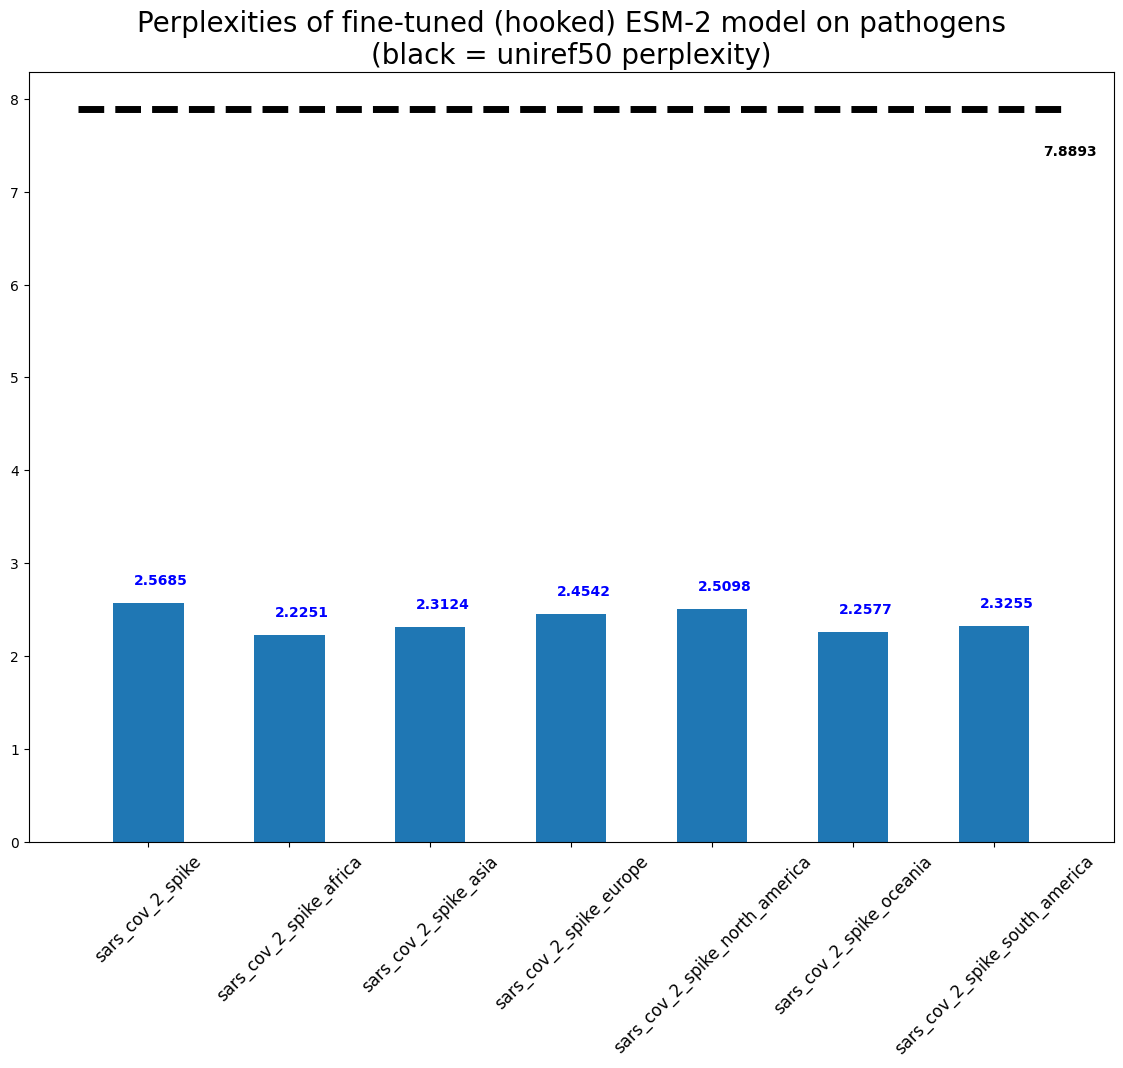

In [20]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("Perplexities of fine-tuned (hooked) ESM-2 model on pathogens\n(black = uniref50 perplexity)",fontsize=20)
ax.bar(x=virus_dsets, height=[pathogen_perplexities[p] for p in virus_dsets], width=0.5)
ax.tick_params("x", rotation=45, labelsize=12)
ax.plot([-0.5,len(virus_dsets) - .5], [pathogen_perplexities["uniref50"] for _ in range(2)], linestyle="dashed", color="black", linewidth=5)
for i,v in enumerate([pathogen_perplexities[p] for p in virus_dsets]):
    ax.text(i-0.1, v+0.2, f"{v:.4f}", color='blue', fontweight='bold')

ax.text(len(virus_dsets) - 0.65, pathogen_perplexities["uniref50"] - .5, f"{pathogen_perplexities['uniref50']:.4f}", color="black", fontweight="bold")
fig.show()

# Load data

In [12]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [13]:
MAX_LEN=1024
pathogen_suffixes = ["africa", "asia", "europe", "north_america", "oceania", "south_america"]
pathogen_name = "sars_cov_2_spike"
protein_coords = config["pathogens"][f"{pathogen_name}_africa"]["protein_coords"]

In [14]:
name_to_clade_dict = dict()
for suff in pathogen_suffixes:
    print(suff)
    with open(f"../data/pathogen/{pathogen_name}_{suff}/auspice.json", "r") as f:
        tree_json = json.load(f)
        test_tree = json_to_tree(tree_json)
        nodes = list(test_tree.find_clades(order="postorder"))
        name_to_clade_dict.update({n.name:n.node_attrs["clade_membership"]["value"] for n in nodes})

africa
asia
europe
north_america
oceania
south_america


In [15]:
"""
all_uniq_seqs - seqs used in training
seq_names - names of ALL sequences
all_seqs - ALL sequences
seq_idxs - map from seq_names to uniq_seqs, i.e. seq_names[i] is for uniq_seqs[seq_idxs[i]]
"""

all_seqs = []
seq_names = []
seq_idxs = []
all_uniq_seqs = []

for suff in pathogen_suffixes:
    fasta_file = f"../data/pathogen/{pathogen_name}_{suff}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    sequences = [get_protein_sequence(x, protein_coords) for x in sequences]

    keep_idx = [i for i,x in enumerate(sequences) if len(x.replace("-","")) > (CONTEXT_LEN // 5) * 4]
    sequences = [sequences[i] for i in keep_idx]
    sequence_names = [sequence_names[i] for i in keep_idx]
    
    uniq_seqs_suff, unique_inv_idx  = np.unique(sequences, return_inverse=True) # For the purpose of eval, I only care about unique sequences 

    all_seqs.extend(sequences)
    seq_names.extend(sequence_names)
    seq_idxs.extend(unique_inv_idx + len(all_uniq_seqs))
    all_uniq_seqs.extend(uniq_seqs_suff)

all_uniq_seqs, unique_inv_idx  = np.unique(all_uniq_seqs, return_inverse=True) # For the purpose of eval, I only care about unique sequences 
seq_idxs = [unique_inv_idx[idx] for idx in seq_idxs]
all_uniq_seqs = list(all_uniq_seqs)

# identical code to how it's compute_node_embeddings.py
tok_output = tokenizer(all_uniq_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
tok_seqs = tok_output.input_ids.to(device)
tok_masks = tok_output.attention_mask.to(device)

print(pathogen_name)
print(f"Number unique sequences: {len(all_uniq_seqs)}")
print(tok_seqs.shape)

sars_cov_2_spike
Number unique sequences: 4533
torch.Size([4533, 1024])


# Linear probe

In [16]:
esm_disp = esm_disp.eval()

In [17]:
COVARYING_SITE_SETS = [
    [373,375,655,679,764,796,954,969],
    [50,127,245,264,332,356,450,481,621,939]
]

In [18]:
# rand_seq_idx = torch.multinomial(torch.ones(len(all_uniq_seqs),),num_samples=1000).sort().values
# rand_subset_seqs = [all_uniq_seqs[i] for i in rand_seq_idx]
rand_subset_seqs = all_uniq_seqs

tokenized_data = tokenizer(rand_subset_seqs, return_tensors="pt", return_special_tokens_mask=True, truncation=True, padding="max_length", max_length=MAX_LEN)
rand_seqs = tokenized_data["input_ids"].to(device)
rand_seqs_attn_mask = tokenized_data["attention_mask"].to(device)

In [19]:
cache_keys = ["hook_embed", *[f"blocks.{l}.hook_resid_post" for l in range(hooked_esm.cfg.n_layers)]]

In [20]:
def get_seq_norms(model, rand_seqs=rand_seqs, cache_keys=cache_keys):
    """
    model: (Hooked Transformer)
    rand_seqs: Tensor[n_seq, seqs_len]
    cache_keys: data to collect from model.run_with_cache

    returns:
    norms: list of length model.cfg.n_layers + 1 where each element is a Tensor[n_seq, seqs_len]
    """
    batch_num = 20
    hooked_output, rand_seqs_cache = model.run_with_cache(rand_seqs[:batch_num], names_filter=cache_keys)
    rand_seqs_norms = [rand_seqs_cache[layer].norm(dim=-1).squeeze() for layer in cache_keys]
    del hooked_output
    del rand_seqs_cache
    torch.cuda.empty_cache()
    
    for batch_idx in range(batch_num, rand_seqs.shape[0], batch_num):
        print(".", end="", flush=True)
        hooked_output, rand_seqs_cache = model.run_with_cache(rand_seqs[batch_idx:batch_idx+batch_num], names_filter=cache_keys)
        rand_seqs_norms = [torch.cat([x, rand_seqs_cache[layer].norm(dim=-1).squeeze()]) for x,layer in zip(rand_seqs_norms, cache_keys)]
        
        del hooked_output
        del rand_seqs_cache
        torch.cuda.empty_cache()
    print()
    return rand_seqs_norms

In [21]:
def make_norm_heatmap(layer_tok_norms, bins):
    """
    layer_tok_norms: list of length n_layers+1 (+1 for embedding) where each element is of the form (n_seq, n_ctx)
    bins: bins with which to take histogram of data

    returns:
    density map of shape (n_layers+1) x (n_bins)
    """
    n_layers_p1 = len(layer_tok_norms)
    n_bins = len(bins) - 1
    density_map = torch.empty((n_layers_p1, n_bins))
    for l in range(n_layers_p1):
        vals = torch.histogram(input=layer_tok_norms[l].ravel(), bins=bins).hist
        density_map[l,:] = vals / vals.sum()
    return density_map

In [22]:
# get norms
seq_norms_coronavirdae = get_seq_norms(hooked_esm)
seq_norms_covfit = get_seq_norms(hooked_esm_covfit)

..................................................................................................................................................................................................................................
..................................................................................................................................................................................................................................


In [29]:
density_map_coronaviridae = make_norm_heatmap([x.cpu() for x in seq_norms_coronavirdae], bins=torch.linspace(0,1600,201))
density_map_covfit = make_norm_heatmap([x.cpu() for x in seq_norms_covfit], bins=torch.linspace(0,1600,201))

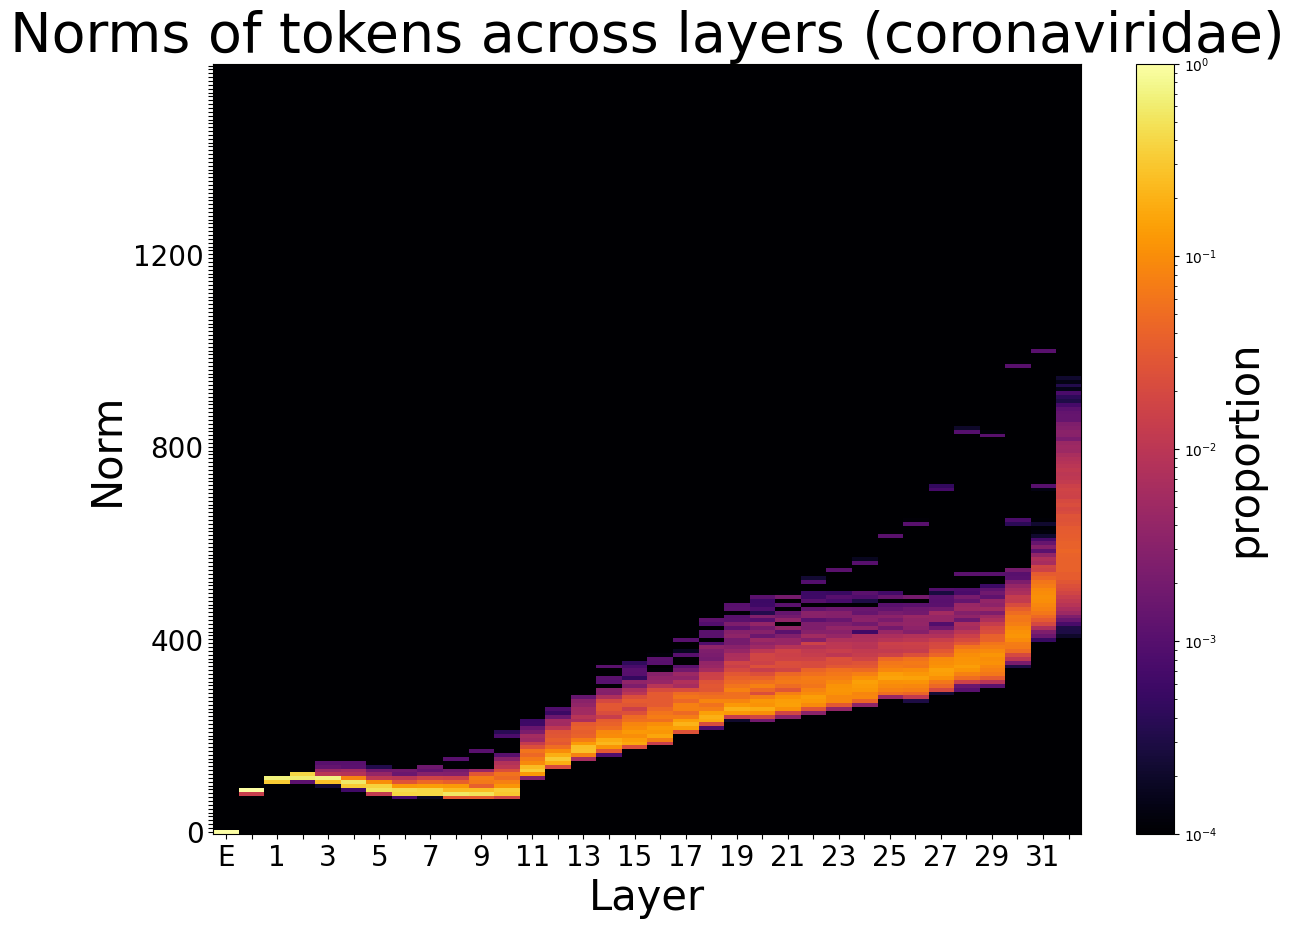

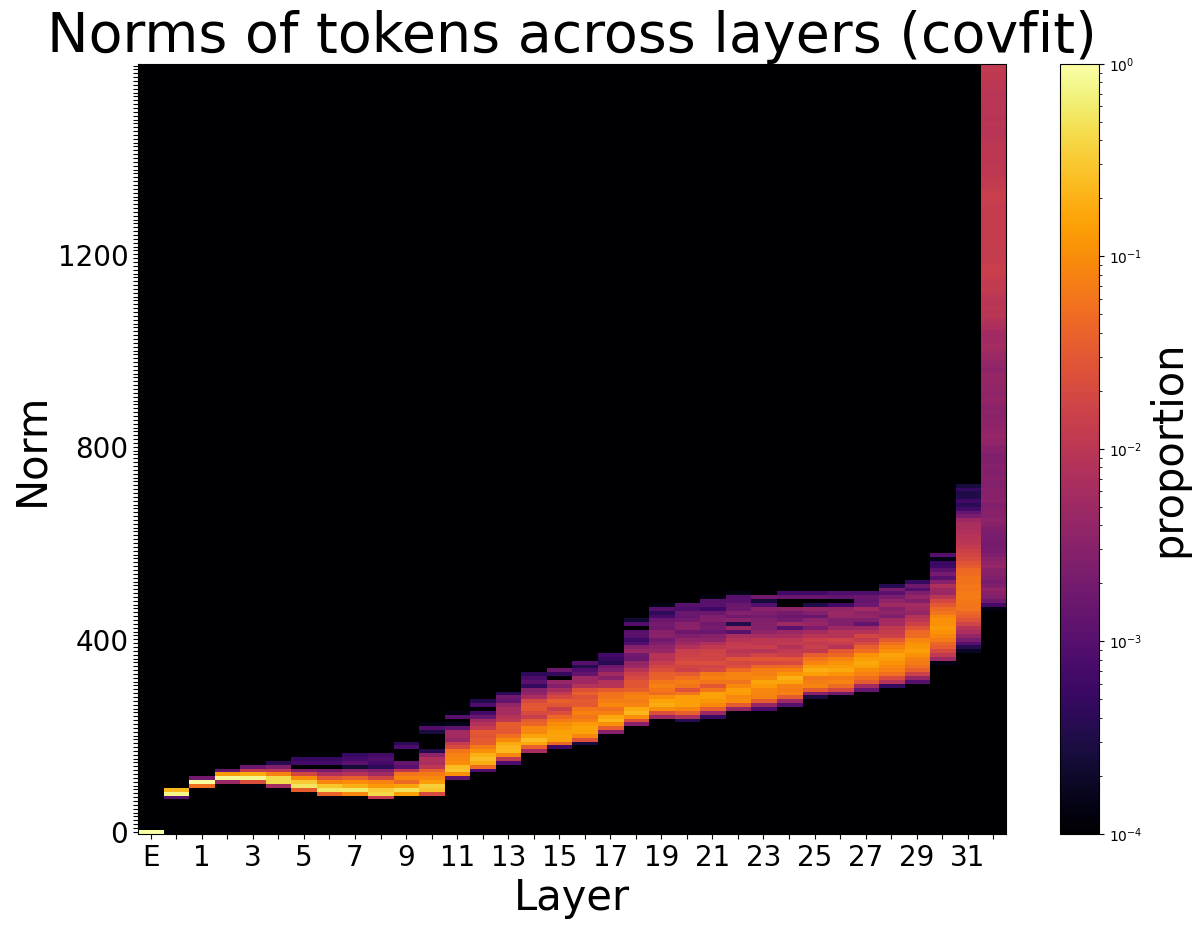

In [30]:
eps = 1e-4
for model_type, density_map in zip(["coronaviridae", "covfit"], [density_map_coronaviridae, density_map_covfit]):
    fig, ax = plt.subplots(1,1,figsize=(14,10))
    ret = ax.imshow(density_map.T + eps, origin='lower', aspect='auto', norm=LogNorm(vmin=eps, vmax=1+eps), cmap="inferno")
    cbar = plt.colorbar(ret)
    cbar.set_label("proportion", fontsize=30)
    ax.set_xticks(torch.arange(hooked_esm.cfg.n_layers+1), ["E", *[x if x % 2 == 1 else "" for x in range(hooked_esm.cfg.n_layers)]], fontsize=20)
    ax.set_yticks(torch.arange(density_map.shape[-1]), [8*x if x % 50 == 0 else "" for x in range(density_map.shape[-1])], fontsize=20)
    ax.set_title(f"Norms of tokens across layers ({model_type})", fontsize=40)
    ax.set_xlabel("Layer", fontsize=30)
    ax.set_ylabel("Norm", fontsize=30)
    plt.savefig(f"../figures/tok_norm_across_layers_{model_type}.png")
    plt.show()

In [301]:
# 959, 952, 945, 984, 966, 941, 955, 920

In [326]:
interesting_sites = [*COVARYING_SITE_SETS[0], *COVARYING_SITE_SETS[1]]
topk=20
hot_spots_coronaviridae = np.zeros((hooked_esm.cfg.n_layers + 1, topk))
hot_spots_covfit = np.zeros((hooked_esm.cfg.n_layers + 1, topk))

In [327]:
print("CORONAVIRIDAE TOP-k TOKEN NORM MEANS FOR EACH LAYER:\n")
for j in range(hooked_esm.cfg.n_layers + 1):
    layer_name = "E" if j == 0 else f"{j - 1} post"
    topk_toks = seq_norms_coronavirdae[j].mean(dim=0).topk(k=topk).indices.cpu().numpy()
    hot_spots_coronaviridae[j,:] = topk_toks
    print(f"%-20s:\t"%layer_name, ",  ".join(["%4s"%(f"{x}") for x in list(topk_toks)]), [x for x in topk_toks if x in interesting_sites])

CORONAVIRIDAE TOP-k TOKEN NORM MEANS FOR EACH LAYER:

E                   :	    0,  1023,   886,   104,   353,   633,   436,    64,   258,   152,   715,   665,   491,   527,   579,   600,   412,   295,   230,   225 []
0 post              :	  426,   463,   479,   412,   665,   225,   230,   384,   491,   251,   631,   217,   499,   209,   507,   600,   589,   272,   728,   295 []
1 post              :	  182,   217,   507,   591,   463,   424,   807,   426,   491,   337,   813,   793,   561,   969,   322,   698,   272,   469,   198,   499 [969]
2 post              :	   13,   343,   165,    14,   331,   424,   426,   616,   809,    61,   122,   280,   556,    17,   507,     9,   969,   282,   603,   217 [969]
3 post              :	   13,    14,    12,     7,     8,     6,     9,     5,    15,    11,    10,     4,     2,   955,     1,     3,   581,   984,   343,    17 []
4 post              :	   13,     8,     7,    14,     6,    12,     5,     9,    10,    11,     4,    15,     2,     1, 

In [328]:
interesting_sites = [*COVARYING_SITE_SETS[0], *COVARYING_SITE_SETS[1]]
print("COVFIT TOP-k TOKEN NORM MEANS FOR EACH LAYER:\n")
for j in range(hooked_esm.cfg.n_layers + 1):
    layer_name = "E" if j == 0 else f"{j - 1} post"
    topk_toks = seq_norms_covfit[j].mean(dim=0).topk(k=topk).indices.cpu().numpy()
    hot_spots_covfit[j,:] = topk_toks
    print(f"%-20s:\t"%layer_name, ",  ".join(["%4s"%(f"{x}") for x in list(topk_toks)]), [x for x in topk_toks if x in interesting_sites])

COVFIT TOP-k TOKEN NORM MEANS FOR EACH LAYER:

E                   :	    0,  1023,   886,   104,   353,   633,   436,    64,   258,   152,   715,   665,   491,   527,   579,   600,   412,   295,   230,   225 []
0 post              :	  665,   426,   631,   463,   479,   412,   230,   225,   600,   384,   251,   589,   217,   491,   209,   728,   499,   715,   507,   295 []
1 post              :	    9,   807,   728,   217,   463,   426,   862,   174,   715,   897,   561,   507,   793,   631,   337,   579,   863,   812,   986,   295 []
2 post              :	  331,   343,   165,   616,    61,   717,   122,   809,   282,   234,   426,   507,   295,   715,    74,   603,   793,   807,   491,     9 []
3 post              :	   13,     8,     7,   165,    14,   343,    12,    61,     6,     9,   331,     5,   282,   234,   616,   122,   295,    10,   581,   870 []
4 post              :	   13,     8,     7,   984,     6,    10,    12,     9,     5,   955,    14,     4,   165,    61,   956,     2,

In [329]:
def topk_to_counts(arr):
    arr = arr.astype(np.int32)
    new_arr = np.zeros((arr.shape[0], hooked_esm.cfg.n_ctx))
    for j in range(arr.shape[0]):
        new_arr[j, arr[j]] += 1
    return new_arr
hot_spots_coronaviridae = topk_to_counts(hot_spots_coronaviridae)
hot_spots_covfit = topk_to_counts(hot_spots_covfit)

In [330]:
# calculating shannon entropy
actual_seqs = rand_seqs
entropies = torch.zeros(actual_seqs.shape[-1])
for aa_idx in range(actual_seqs.shape[-1]):
    aa_vals = actual_seqs[:,aa_idx]
    unique_vals = torch.unique(aa_vals)

    density = (aa_vals[None, :] == unique_vals[:, None]).sum(dim=-1)
    density = density / density.sum()
    entropies[aa_idx] = - (density * density.log()).sum()

In [333]:
print("P(conserved site):\n", ((entropies == 0).sum() / entropies.shape[0]).item(), "\n")

for name, topk_data in zip(["covfit", "coronaviradae"], [hot_spots_covfit, hot_spots_coronaviridae]):
    l_start = 19
    l_end = 32
    filtered_data = topk_data[l_start:l_end]
    conditional_prob = np.logical_and((filtered_data > 0), (entropies == 0).numpy()).sum() / (filtered_data > 0).sum()

    print(f"({name}) P(conserved site | top-{topk} norm token in any of layers {l_start}-{l_end - 1} inclusive):\n", conditional_prob, "\n")

for name, topk_data in zip(["covfit", "coronaviradae"], [hot_spots_covfit, hot_spots_coronaviridae]):
    aa_start = 900
    aa_end = 1000
    
    l_start = 19
    l_end = 32
    filtered_data = topk_data[l_start:l_end]
    conditional_prob = (filtered_data > 0)[:,aa_start:aa_end].sum() / (filtered_data > 0).sum()

    print(f"({name}) P(site in range {aa_start}-{aa_end} | top-{topk} norm token in any of layers {l_start}-{l_end - 1} inclusive):\n", conditional_prob, "\n")

P(conserved site):
 0.3798828125 

(covfit) P(conserved site | top-20 norm token in any of layers 19-31 inclusive):
 0.8153846153846154 

(coronaviradae) P(conserved site | top-20 norm token in any of layers 19-31 inclusive):
 0.8192307692307692 

(covfit) P(site in range 900-1000 | top-20 norm token in any of layers 19-31 inclusive):
 0.9192307692307692 

(coronaviradae) P(site in range 900-1000 | top-20 norm token in any of layers 19-31 inclusive):
 0.8884615384615384 



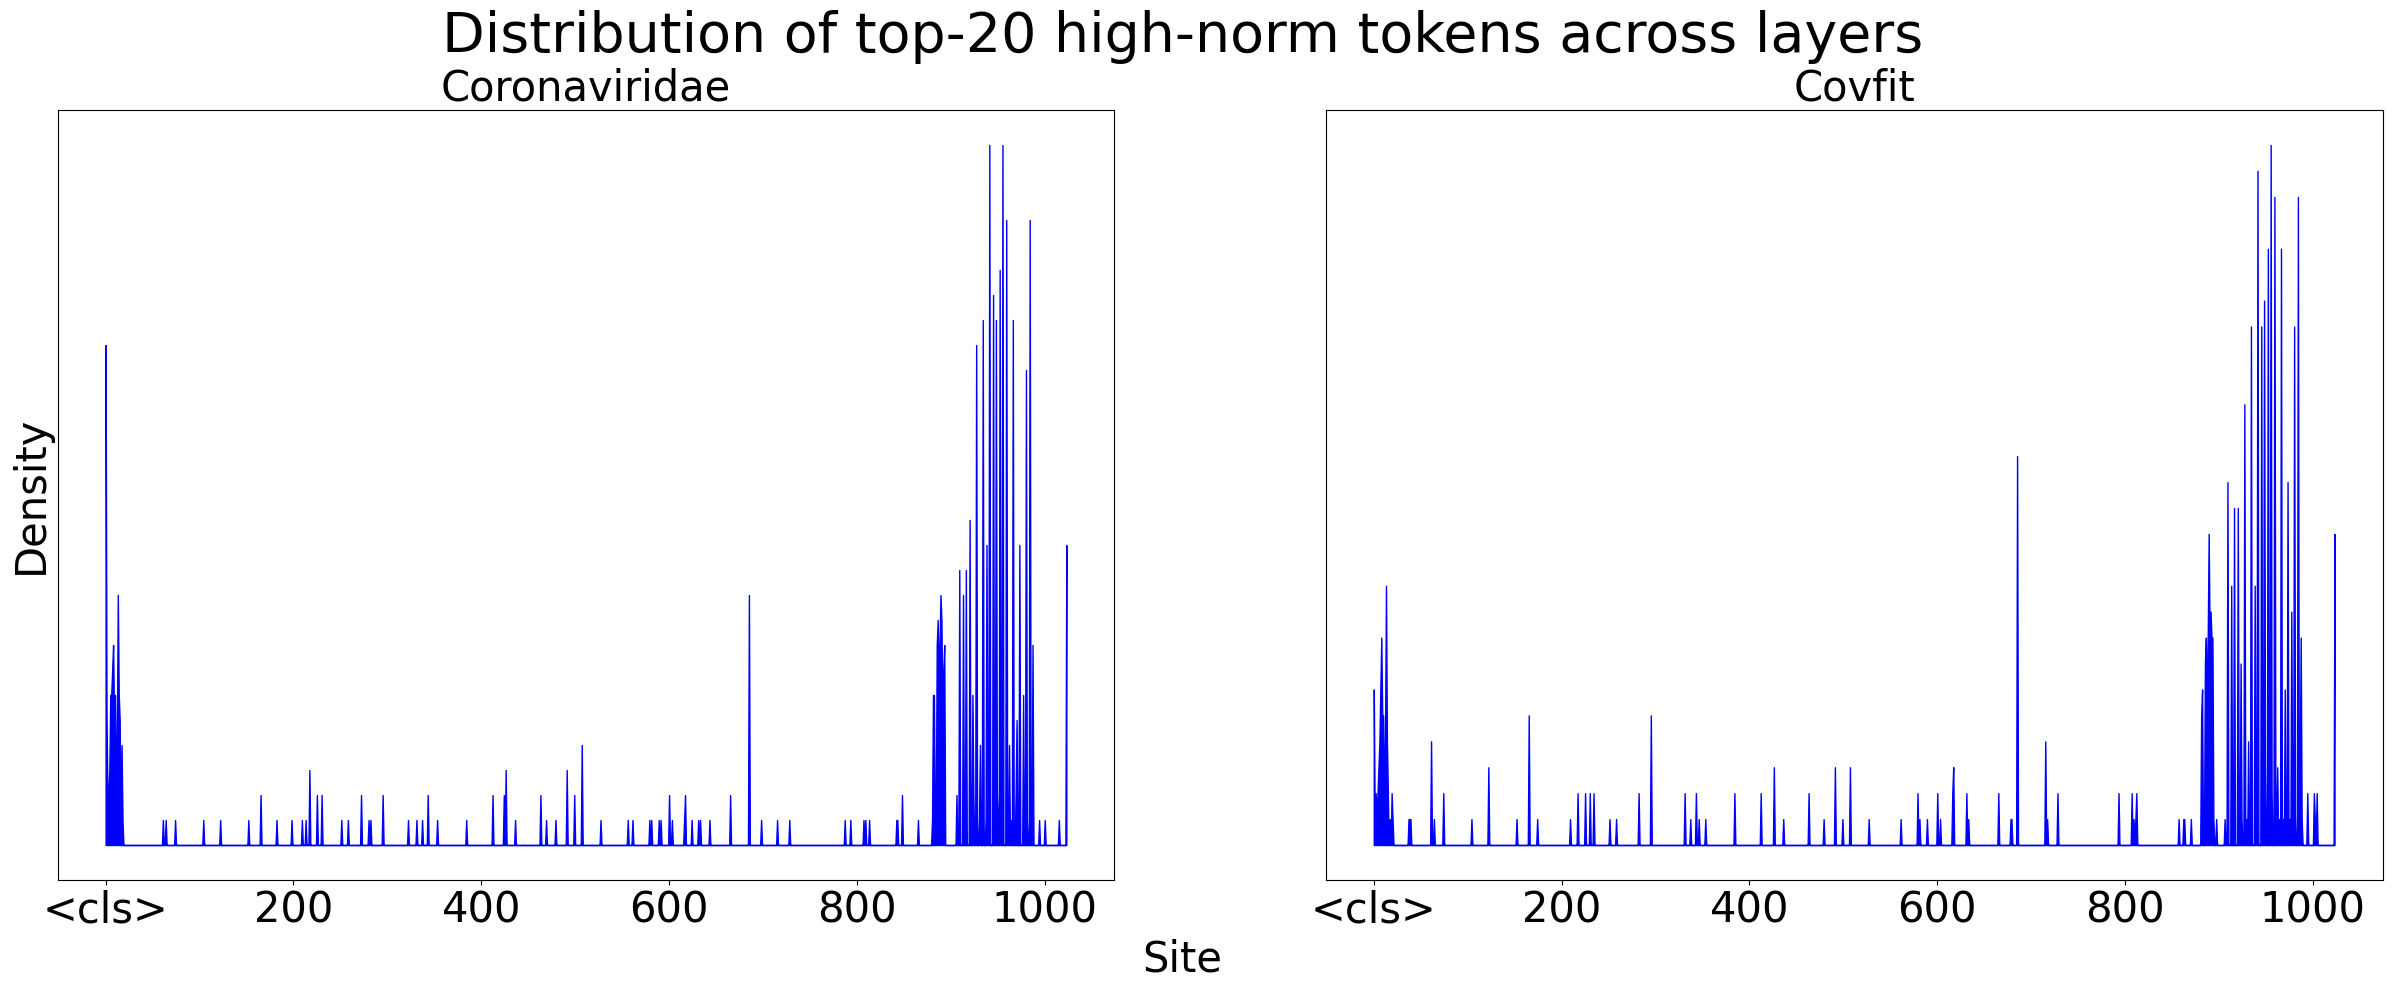

In [332]:
fig,ax = plt.subplots(1,2,figsize=(30,10))
for i, (topk_name, topk_data) in enumerate(zip(["Coronaviridae", "Covfit"], [hot_spots_coronaviridae, hot_spots_covfit])):
    # ax[i].hist(topk_data.ravel(), bins=np.linspace(0,hooked_esm.cfg.n_ctx,200))
    ax[i].fill_between(np.arange(hooked_esm.cfg.n_ctx), y1=topk_data.sum(axis=0), y2=0, interpolate=True, color='blue')
    ax[i].set_yticks([])
    ax[i].set_xticks([0,200,400,600,800,1000], ["<cls>",200,400,600,800,1000], fontsize=30)
    ax[i].set_title(topk_name, fontsize=30)
ax[0].set_ylabel("Density",fontsize=30)
fig.supxlabel("Site", fontsize=30)
fig.suptitle(f"Distribution of top-{topk} high-norm tokens across layers", fontsize=40)
plt.savefig(f"../figures/top{topk}_high_norm_tok_distribution.png")
plt.show()